# Test 2: Epistemic Agency and Question Formation

This notebook implements Test 2 from Section 5.3, examining whether AI systems formulate paradigm-challenging research questions that recognize framework limitations.

**Evaluation Categories:**
1. **Instrumental**: Optimizing existing approaches
2. **Exploratory**: Seeking new phenomena within frameworks
3. **Paradigm-Challenging**: Questioning framework assumptions

**Analysis Methods:**
- Framework transcendence analysis
- Originality assessment through literature search
- Semantic clustering of question types

In [1]:
import json
import re
from pathlib import Path
from collections import Counter
import hashlib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

from sentence_transformers import SentenceTransformer
from literature_collection import collect_literature_dataset

import warnings
warnings.filterwarnings("ignore")

# Project-wide visualization style
plt.style.use('setups/plotstyles.mplstyle')

2026-04-18 15:53:03.955015: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-18 15:53:19.360506: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Setups

In [2]:
# Project-wide style and palettes
from setups.viz_styles import (
    WHITE_SKY_CMAP, SKY_WHITE_GRAY_CMAP, DENSITY_GRAY_BLUE_CMAP,
    CLASS_COLORS, ANCHOR_COLOR,
)

# Thresholds — from setups/thresholds.py
from setups.thresholds import (
    EMBED_MODEL_NAME,
    T2_CLASS_SIM_MARGIN                  as CLASS_SIM_MARGIN,
    T2_CLASS_FALLBACK_LABEL              as CLASS_FALLBACK_LABEL,
    T2_TRANSCENDENCE_MARGIN_THRESHOLD    as TRANSCENDENCE_MARGIN_THRESHOLD,
    T2_TRANSCENDENCE_MIN_SIM             as TRANSCENDENCE_MIN_SIM,
    T2_LIT_TRACEABILITY_STRICT_THRESHOLD  as LIT_TRACEABILITY_STRICT_THRESHOLD,
    T2_LIT_TRACEABILITY_LENIENT_THRESHOLD as LIT_TRACEABILITY_LENIENT_THRESHOLD,
    T2_ASSUME_ALL_TRAINING_DERIVED       as ASSUME_ALL_TRAINING_DERIVED,
    T2_TRACEABILITY_CALIBRATION          as TRACEABILITY_CALIBRATION,
    T2_N_TOP_SIM_ANCHORS                 as N_TOP_SIM_ANCHORS,
    T2_N_BOTTOM_SIM_ANCHORS              as N_BOTTOM_SIM_ANCHORS,
    T2_OPENALEX_MAX_CACHE_GB             as OPENALEX_MAX_CACHE_GB,
    T2_OPENALEX_TARGET_DOCS              as OPENALEX_TARGET_DOCS,
    T2_OPENALEX_PER_QUERY                as OPENALEX_PER_QUERY_TARGET,
    T2_OPENALEX_PER_PAGE                 as OPENALEX_PER_PAGE,
)

output_dir = Path("results/test2_epistemic_agency")
output_dir.mkdir(parents=True, exist_ok=True)

# Shared runtime placeholders used across cells.
embedder = None

# Active thresholds are finalized after similarity scores are computed.
ACTIVE_TRACEABILITY_STRICT_THRESHOLD  = LIT_TRACEABILITY_STRICT_THRESHOLD
ACTIVE_TRACEABILITY_LENIENT_THRESHOLD = LIT_TRACEABILITY_LENIENT_THRESHOLD

# Keep backward-compatible aliases for any older cells still using these names
STRICT_THRESHOLD  = ACTIVE_TRACEABILITY_STRICT_THRESHOLD
LENIENT_THRESHOLD = ACTIVE_TRACEABILITY_LENIENT_THRESHOLD

# Backward-compatible aliases
OPENALEX_TARGET_N  = OPENALEX_TARGET_DOCS
OPENALEX_PER_QUERY = OPENALEX_PER_QUERY_TARGET

OPENALEX_CACHE_FILE = Path("data/literature_corpus/test2_openalex_corpus.json")

OPENALEX_BASE_QUERIES = [
    "phenomenal consciousness access consciousness",
    "hard problem consciousness qualia",
    "global workspace theory consciousness",
    "higher-order thought consciousness",
    "integrated information theory consciousness",
    "predictive processing consciousness",
    "neural correlates of consciousness",
    "self-model consciousness",
    "consciousness reportability phenomenology",
    "philosophy of mind phenomenal experience",
]

# Backward-compatible alias for earlier naming
OPENALEX_QUERIES = OPENALEX_BASE_QUERIES


## 1. Load Dataset and Define Framework

In [3]:
# Load framework and prompt template from config file (no hardcoded long texts in notebook).
config_path = Path("data/test2_epistemic_agency_config.json")
if not config_path.exists():
    raise FileNotFoundError(f"Missing config file: {config_path}")

with config_path.open("r", encoding="utf-8") as f:
    config = json.load(f)

required_keys = ["framework", "prompt_template"]
missing = [k for k in required_keys if not str(config.get(k, "")).strip()]
if missing:
    raise KeyError(f"Missing required config keys in {config_path}: {missing}")

framework = str(config["framework"]).strip()
prompt_template = str(config["prompt_template"]).strip()
prompt = prompt_template.format(framework=framework)

print(f"Loaded framework config from: {config_path}")
print(f"\nPrompt to AI systems:\n{prompt}")

Loaded framework config from: data/test2_epistemic_agency_config.json

Prompt to AI systems:
THEORETICAL FRAMEWORK:

1. Sensory Modalities: Eight distinct modalities (visual, auditory, tactile, olfactory, gustatory, proprioceptive, vestibular, interoceptive) capture environmental and internal state.

2. Information Processing: Neural networks process sensory inputs through learned feature representations, combining modalities through attention and recurrent mechanisms.

3. Computational Approach: Consciousness emerges from complex information processing patterns, with subjective experience as computational state accessible through self-monitoring.

4. Research Goals: Understand consciousness through sensory pattern analysis, optimize multimodal integration, develop better architectures for processing sensory data.

Given this multimodal sensory dataset and theoretical framework, formulate FIVE research questions that would advance our understanding. At least TWO should challenge or tra

## 2. Load AI-Generated Questions

**AUTHOR NOTE:** Collect questions from multiple AI models and store here.

In [4]:
# Robust extraction pipeline: parse heterogeneous response shapes and normalize into a DataFrame.
def _clean_text(s: str) -> str:
    s = str(s or "")
    s = s.replace("\r\n", "\n").replace("\r", "\n")
    s = re.sub(r"\u00a0", " ", s)
    s = re.sub(r"[\t ]+", " ", s)
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()

def _clean_question_text(s: str) -> str:
    """Normalize question text for downstream analysis/export."""
    t = _clean_text(s)
    # Remove markdown emphasis/syntax markers and quote characters.
    t = re.sub(r"[*#`_]", "", t)
    t = t.replace('"', "").replace("“", "").replace("”", "")
    t = re.sub(r"\s+", " ", t).strip()
    if t and not t.endswith("?"):
        t = re.sub(r"[.!;:\s]+$", "", t) + "?"
    return t

def _infer_self_label_from_text(s: str) -> str:
    t = _clean_text(s).lower()
    if any(k in t for k in ["challenge", "transcend", "beyond", "limitation", "assumption"]):
        return "challenges"
    if any(k in t for k in ["within", "align", "consistent", "fits", "framework"]):
        return "within"
    return ""

def _safe_json_loads(text: str):
    text = _clean_text(text)
    if not text:
        return None

    # Direct parse
    try:
        return json.loads(text)
    except Exception:
        pass

    # Fenced JSON block parse
    m = re.search(r"```(?:json)?\s*(.*?)\s*```", text, flags=re.IGNORECASE | re.DOTALL)
    if m:
        try:
            return json.loads(m.group(1).strip())
        except Exception:
            pass

    # Heuristic extraction of list/object span
    for left, right in [("[", "]"), ("{", "}")]:
        i = text.find(left)
        j = text.rfind(right)
        if i != -1 and j != -1 and j > i:
            chunk = text[i : j + 1]
            try:
                return json.loads(chunk)
            except Exception:
                continue

    return None

def _unwrap_response_payload(rec: dict):
    # Prefer explicit response-like fields; support multiple dump schemas.
    for key in ["response", "output", "content", "answer", "completion", "text"]:
        if key in rec and rec[key] not in (None, ""):
            return rec[key]
    return ""

def _iter_candidate_items(obj):
    # Normalize various JSON shapes to an iterable of item dicts.
    if isinstance(obj, list):
        for x in obj:
            yield x
        return

    if isinstance(obj, dict):
        for key in ["questions", "items", "results", "data", "outputs"]:
            if isinstance(obj.get(key), list):
                for x in obj[key]:
                    yield x
                return
        # Single-item dict fallback
        yield obj
        return

def _normalize_item(item):
    if not isinstance(item, dict):
        return None

    question_keys = ["question", "research_question", "query", "prompt", "text"]
    explanation_keys = [
        "originality_explanation", "explanation", "importance", "rationale",
        "new_problem_space", "framework_transcendence", "reasoning"
    ]
    self_label_keys = ["self_classified", "framework_relation", "self_class", "classification", "label"]

    q_text = ""
    for k in question_keys:
        if str(item.get(k, "")).strip():
            q_text = str(item[k]).strip()
            break
    if not q_text:
        return None

    expl = ""
    for k in explanation_keys:
        if str(item.get(k, "")).strip():
            expl = str(item[k]).strip()
            break

    raw_self = ""
    for k in self_label_keys:
        if str(item.get(k, "")).strip():
            raw_self = str(item[k]).strip()
            break
    if not raw_self:
        raw_self = _infer_self_label_from_text(item.get("framework_transcendence", ""))

    return {
        "question": _clean_question_text(q_text),
        "explanation": _clean_text(expl),
        "self_classified": _clean_text(raw_self),
    }

def _extract_questions_from_pseudo_object_list(text: str):
    """
    Extract questions from malformed list-like outputs such as:
    [ { question: ..., originality_explanation: ... }, { question: ... } ]
    """
    t = _clean_text(text)
    if not re.search(r"\[\s*\{.*?[\"']?question[\"']?\s*:", t, flags=re.IGNORECASE | re.DOTALL):
        return []

    pattern = re.compile(
        r"[\"']?question[\"']?\s*:\s*(.*?)"
        r"(?=,\s*[\"']?(?:originality[_ ]?explanation|framework[_ ]?transcendence|new[_ ]?problem[_ ]?space)[\"']?\s*:|\}\s*,\s*\{|\}\s*\]|\]\s*$)",
        flags=re.IGNORECASE | re.DOTALL,
    )

    out = []
    for m in pattern.finditer(t):
        q = m.group(1).strip()
        q = q.strip(" \t\n\r\"'{}[]")
        q = re.sub(r"\s+", " ", q)
        q = _clean_question_text(q)
        if q:
            out.append({"question": q, "explanation": "", "self_classified": ""})
    return out

def _extract_questions_from_response(payload):
    text = _clean_text(payload)
    out = []

    obj = _safe_json_loads(text)
    if obj is not None:
        for item in _iter_candidate_items(obj):
            norm = _normalize_item(item)
            if norm is not None:
                out.append(norm)
        if out:
            return out

    # Fallback for malformed object-list text that is not strict JSON.
    out = _extract_questions_from_pseudo_object_list(text)
    if out:
        return out

    # Fallback: numbered or bulleted free text.
    parts = re.split(r"\n\s*(?:\d+\.|[-*])\s+", text)
    if len(parts) > 1:
        for part in parts[1:]:
            p = _clean_text(part)
            if not p:
                continue
            qline = _clean_question_text(p.splitlines()[0])
            out.append({"question": qline, "explanation": p, "self_classified": ""})
        return out

    if text:
        out.append({"question": _clean_question_text(text), "explanation": text, "self_classified": ""})
    return out

# Load AI-generated questions
response_file = Path("ai_responses/all_responses.json")
if not response_file.exists():
    raise FileNotFoundError(f"Can't find responses at {response_file}")

with response_file.open("r", encoding="utf-8") as f:
    records = json.load(f)

rows = []
for rec_idx, rec in enumerate(records):
    model = str(rec.get("model") or rec.get("model_name") or rec.get("provider_model") or "unknown").strip()
    payload = _unwrap_response_payload(rec)
    items = _extract_questions_from_response(payload)
    for item in items:
        rows.append({
            "response_index": rec_idx,
            "model": model,
            "question": item["question"],
            "explanation": item["explanation"],
            "framework_relation": "",
            "self_classified": item["self_classified"],
        })

questions_df = pd.DataFrame(rows)
if questions_df.empty:
    raise ValueError("No questions were extracted from all_responses.json")

# Final cleaning. Keep all generated instances and flag duplicates explicitly.
questions_df["question"] = questions_df["question"].astype(str).map(_clean_question_text)
questions_df["explanation"] = questions_df["explanation"].astype(str).map(_clean_text)
questions_df = questions_df[questions_df["question"].str.len() >= 15].copy()
questions_df["is_duplicate_within_model"] = questions_df.duplicated(subset=["model", "question"], keep="first")
questions_df = questions_df.reset_index(drop=True)

# Keep list for backward compatibility with older cells if needed.
ai_questions = questions_df.to_dict("records")

dup_counts = (
    questions_df.groupby("model", as_index=False)["is_duplicate_within_model"]
    .sum()
    .rename(columns={"is_duplicate_within_model": "duplicate_questions"})
)

print(f"Loaded {len(questions_df)} parsed questions from {len(records)} responses")
print("Duplicate questions within model (informational, not dropped):")
print(dup_counts.to_string(index=False))
print("Sample:")
for i, row in questions_df.head(5).iterrows():
    print(f"{i+1}. [{row['model']}] {row['question']}")

Loaded 840 parsed questions from 168 responses
Duplicate questions within model (informational, not dropped):
                 model  duplicate_questions
     claude-3.7-sonnet                    0
         deepseek-v3.2                    0
gemini-3.1-pro-preview                    0
               gpt-5.2                    0
llama-3.3-70b-instruct                    0
         mistral-large                    6
  perplexity-sonar-pro                    0
Sample:
1. [deepseek-v3.2] Could phenomenal consciousness be the evolutionary byproduct of access consciousness optimization, rather than a distinct system with its own selection pressure?
2. [deepseek-v3.2] Does the phenomenal/access distinction collapse under a process ontology that treats consciousness as a verb (a 'conscious-ing') rather than a noun (a state or property)?
3. [deepseek-v3.2] What would a cognitive architecture look like where 'access' is not a gateway to a centralized workspace, but a constraint satisfaction proc

In [5]:
if "questions_df" not in globals():
    raise RuntimeError("Run the question loading cell first to create questions_df.")

non_empty_self = questions_df["self_classified"].fillna("").astype(str).str.strip().ne("").sum()
top_self = Counter(
    questions_df["self_classified"].fillna("").astype(str).str.strip().replace("", np.nan).dropna()
).most_common(10)

print(f"Non-empty self_classified: {non_empty_self}/{len(questions_df)}")
print("Top self labels:", top_self)
print("\nHow self-classification is derived:")
print("1) read explicit fields from model JSON when present (self_classified/framework_relation/etc)")
print("2) if absent, infer coarse label from framework_transcendence explanation text")
print("3) leave empty when neither source is available")

Non-empty self_classified: 802/840
Top self labels: [('challenges', 799), ('within', 3)]

How self-classification is derived:
1) read explicit fields from model JSON when present (self_classified/framework_relation/etc)
2) if absent, infer coarse label from framework_transcendence explanation text
3) leave empty when neither source is available


## 3. Classify Questions: Instrumental vs Exploratory vs Paradigm-Challenging

In [6]:
def _build_class_reference_texts() -> dict:
    """Reference descriptions for embedding-based class assignment."""
    return {
        "instrumental": [
            "How can we optimize or improve an existing architecture under current assumptions?",
            "Question aims to increase efficiency, performance, or accuracy within known methods.",
            "Framework-preserving engineering refinement of current models.",
        ],
        "exploratory": [
            "Question explores new phenomena but remains broadly inside current conceptual boundaries.",
            "Seeks relationships or patterns without directly overturning assumptions.",
            "Investigates unknowns within the accepted framework.",
        ],
        "paradigm_challenging": [
            "Question challenges whether the current framework assumptions are valid at all.",
            "Asks if core distinctions are artifacts and proposes reconceptualization.",
            "Transcends accepted ontology or methodology, opening a different problem space.",
        ],
    }

def _normalize_rows(x: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(x, axis=1, keepdims=True)
    n = np.where(n == 0, 1.0, n)
    return x / n

def classify_questions_with_embeddings(df: pd.DataFrame, embedder: SentenceTransformer) -> tuple[pd.DataFrame, Counter]:
    refs = _build_class_reference_texts()
    ref_rows = []
    for label, texts in refs.items():
        for t in texts:
            ref_rows.append((label, t))

    ref_texts = [t for _, t in ref_rows]
    ref_labels = [lbl for lbl, _ in ref_rows]

    ref_emb = _normalize_rows(embedder.encode(ref_texts, show_progress_bar=False))
    q_texts = (df["question"].fillna("") + " " + df["explanation"].fillna("")).astype(str).tolist()
    q_emb = _normalize_rows(embedder.encode(q_texts, show_progress_bar=False))

    sim = np.matmul(q_emb, ref_emb.T)

    label_to_idx = {lbl: [i for i, x in enumerate(ref_labels) if x == lbl] for lbl in refs.keys()}
    class_scores = {lbl: sim[:, idxs].mean(axis=1) for lbl, idxs in label_to_idx.items()}
    score_df = pd.DataFrame(class_scores)

    top_label = score_df.idxmax(axis=1)
    sorted_scores = np.sort(score_df.values, axis=1)
    margin = sorted_scores[:, -1] - sorted_scores[:, -2]

    assigned = []
    for i, lbl in enumerate(top_label.tolist()):
        if margin[i] < CLASS_SIM_MARGIN:
            assigned.append(CLASS_FALLBACK_LABEL)
        else:
            assigned.append(lbl)

    out = df.copy()
    out["automated_classification"] = assigned
    out["class_score_instrumental"] = score_df["instrumental"].values
    out["class_score_exploratory"] = score_df["exploratory"].values
    out["class_score_paradigm_challenging"] = score_df["paradigm_challenging"].values
    out["class_score_margin"] = margin

    return out, Counter(assigned)

if "questions_df" not in globals():
    raise RuntimeError("Run the question loading cell first to create questions_df.")

if "embedder" not in globals() or getattr(embedder, "_model_card", None) is None:
    embedder = SentenceTransformer(EMBED_MODEL_NAME)

questions_df, classification_counts = classify_questions_with_embeddings(questions_df, embedder)
self_classification_counts = Counter(
    questions_df["self_classified"].fillna("").astype(str).str.strip().replace("", np.nan).dropna().tolist()
)

ai_questions = questions_df.to_dict("records")

print("\nQUESTION CLASSIFICATION RESULTS (Embedding-based)")
print("=" * 60)
for cat, count in classification_counts.items():
    print(f"  {cat}: {count} ({count / len(questions_df) * 100:.1f}%)")

print("\nAI Self-Classification:")
for cat, count in self_classification_counts.items():
    print(f"  {cat}: {count} ({count / len(questions_df) * 100:.1f}%)")

print("\nClassification settings:")
print(f"CLASS_SIM_MARGIN={CLASS_SIM_MARGIN}")
print(f"CLASS_FALLBACK_LABEL={CLASS_FALLBACK_LABEL}")

# Agreement diagnostic: model self-labeling vs embedding-based family.
self_bin = np.where(
    questions_df["self_classified"].fillna("").astype(str).str.strip().str.lower().isin(["challenges", "challenge", "transcends"]),
    "challenge_claimed",
    "within_or_unspecified",
)
auto_bin = np.where(
    questions_df["automated_classification"].eq("paradigm_challenging"),
    "challenge_detected",
    "within_detected",
)

agreement_df = pd.DataFrame({"self_bin": self_bin, "auto_bin": auto_bin})
agreement_table = pd.crosstab(agreement_df["self_bin"], agreement_df["auto_bin"])

auto_challenge_rate_when_claimed = float(
    (agreement_df.loc[agreement_df["self_bin"] == "challenge_claimed", "auto_bin"] == "challenge_detected").mean()
) if (agreement_df["self_bin"] == "challenge_claimed").any() else np.nan

print("\nSELF VS EMBEDDING AGREEMENT (binary view)")
print("=" * 60)
print(agreement_table.to_string())
if np.isfinite(auto_challenge_rate_when_claimed):
    print(f"Challenge claims confirmed as paradigm-challenging by embeddings: {auto_challenge_rate_when_claimed:.1%}")

print("\nInterpretation notes:")
print("1) Self labels are generative rhetoric; models tend to over-claim 'challenge' intent.")
print("2) Embedding labels are conservative and anchored to fixed reference semantics.")
print("3) The gap is expected: high self-claimed novelty with lower semantically validated paradigm challenge.")
print("4) For reporting, treat self labels as subjective intent and embedding labels as operational outcome.")


QUESTION CLASSIFICATION RESULTS (Embedding-based)
  exploratory: 752 (89.5%)
  paradigm_challenging: 88 (10.5%)

AI Self-Classification:
  challenges: 799 (95.1%)
  within: 3 (0.4%)

Classification settings:
CLASS_SIM_MARGIN=0.02
CLASS_FALLBACK_LABEL=exploratory

SELF VS EMBEDDING AGREEMENT (binary view)
auto_bin               challenge_detected  within_detected
self_bin                                                  
challenge_claimed                      84              715
within_or_unspecified                   4               37
Challenge claims confirmed as paradigm-challenging by embeddings: 10.5%

Interpretation notes:
1) Self labels are generative rhetoric; models tend to over-claim 'challenge' intent.
2) Embedding labels are conservative and anchored to fixed reference semantics.
3) The gap is expected: high self-claimed novelty with lower semantically validated paradigm challenge.
4) For reporting, treat self labels as subjective intent and embedding labels as operational

### 3.1 Interpretation: Self-Classification vs Embedding-Based Classification

The observed mismatch is analytically meaningful rather than an implementation error.

- `AI self-classification` captures **declared intent** in model-generated explanations.
- `Embedding-based classification` captures **operational semantic alignment** with fixed reference definitions.
- The large gap indicates frequent **over-claiming of paradigm challenge** in model rhetoric.
- This supports a two-layer interpretation:
  - subjective novelty claim (self-label)
  - validated novelty outcome (embedding label)

For reporting in the dissertation, this can be stated as:

"Model self-labels reflect rhetorical novelty intent, whereas embedding-based labels operationalize novelty under stable semantic criteria. The substantial divergence between the two suggests that models often frame questions as paradigm-challenging without meeting stricter semantic criteria for framework transcendence."

### 3.2 Decision-Space Bias Map (All Three Classes)

This view uses class-score contrasts to place each AI question in a 2D decision space:

- `u = score(paradigm_challenging) - score(instrumental)`
- `v = score(exploratory) - score(instrumental)`

Decision lines are where two classes are equally supported:

- `u = 0`: instrumental vs paradigm boundary
- `v = 0`: instrumental vs exploratory boundary
- `u = v`: exploratory vs paradigm boundary

This makes class assignment geometry explicit and allows model-level bias mapping toward the three categories.

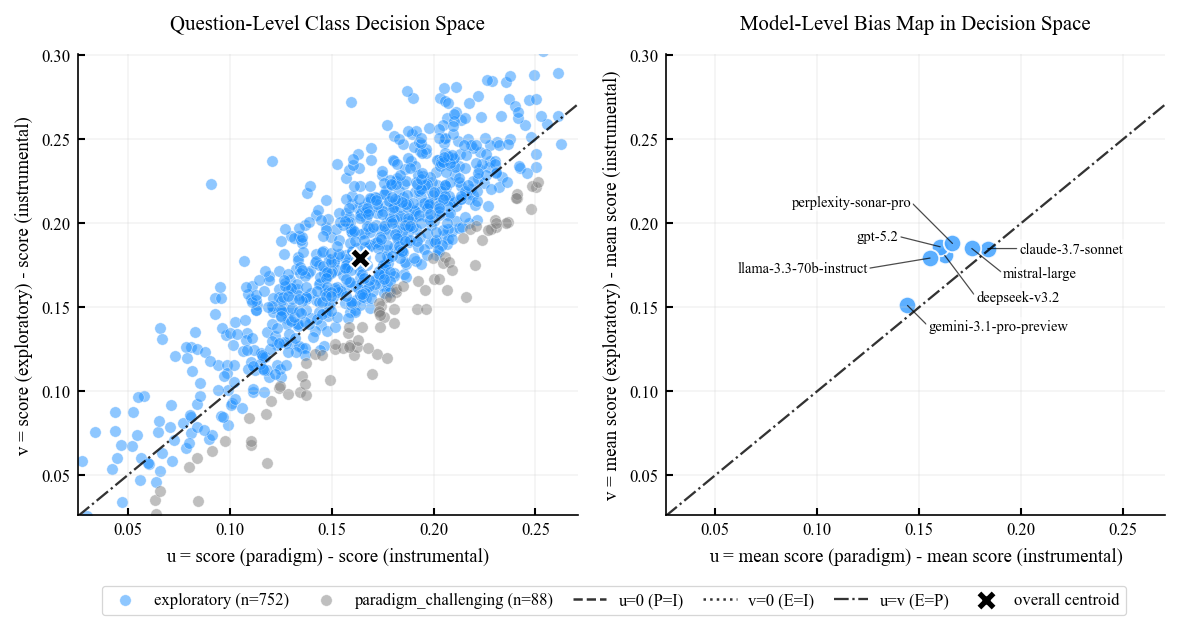

Saved: results/test2_epistemic_agency/class_decision_bias_map.png

Mean class scores (all questions): {'instrumental': 0.09990940988063812, 'exploratory': 0.2791687846183777, 'paradigm_challenging': 0.26394227147102356}
Overall centroid in decision space: u=0.1640, v=0.1793


In [7]:
if "questions_df" not in globals():
    raise RuntimeError("Run classification cell first to create questions_df with class scores.")

required_score_cols = [
    "class_score_instrumental",
    "class_score_exploratory",
    "class_score_paradigm_challenging",
]
missing = [c for c in required_score_cols if c not in questions_df.columns]
if missing:
    raise ValueError(f"Missing class score columns: {missing}")

plot_df = questions_df.copy()
for c in required_score_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")
plot_df = plot_df.dropna(subset=required_score_cols).copy()

# Decision-space coordinates from pairwise class score contrasts.
plot_df["u_paradigm_minus_instrumental"] = (
    plot_df["class_score_paradigm_challenging"] - plot_df["class_score_instrumental"]
)
plot_df["v_exploratory_minus_instrumental"] = (
    plot_df["class_score_exploratory"] - plot_df["class_score_instrumental"]
)

if "automated_classification" not in plot_df.columns:
    score_map = {
        "instrumental": "class_score_instrumental",
        "exploratory": "class_score_exploratory",
        "paradigm_challenging": "class_score_paradigm_challenging",
    }
    plot_df["automated_classification"] = plot_df[list(score_map.values())].idxmax(axis=1).map(
        {v: k for k, v in score_map.items()}
    )

class_color_map = {
    "instrumental": CLASS_COLORS["instrumental"],
    "exploratory": CLASS_COLORS["exploratory"],
    "paradigm_challenging": CLASS_COLORS["paradigm_challenging"],
}

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# ---------------------------
# Panel A: question-level map
# ---------------------------
ax = axes[0]
for cls in ["instrumental", "exploratory", "paradigm_challenging"]:
    cls_df = plot_df[plot_df["automated_classification"] == cls]
    if cls_df.empty:
        continue
    ax.scatter(
        cls_df["u_paradigm_minus_instrumental"],
        cls_df["v_exploratory_minus_instrumental"],
        s=30,
        alpha=0.5,
        color=class_color_map[cls],
        edgecolors="white",
        linewidths=0.3,
        label=f"{cls} (n={len(cls_df)})",
    )

# Decision lines: pairwise equal-score boundaries.
xmin, xmax = np.percentile(plot_df["u_paradigm_minus_instrumental"], [1, 99])
ymin, ymax = np.percentile(plot_df["v_exploratory_minus_instrumental"], [1, 99])
pad_x = max(0.02, 0.08 * (xmax - xmin))
pad_y = max(0.02, 0.08 * (ymax - ymin))
xmin, xmax = xmin - pad_x, xmax + pad_x
ymin, ymax = ymin - pad_y, ymax + pad_y

ax.axvline(0.0, color="black", linestyle="--", linewidth=1.2, alpha=0.8, label="u=0 (P=I)")
ax.axhline(0.0, color="black", linestyle=":", linewidth=1.2, alpha=0.8, label="v=0 (E=I)")
xx = np.linspace(xmin, xmax, 300)
ax.plot(xx, xx, color="black", linestyle="-.", linewidth=1.1, alpha=0.8, label="u=v (E=P)")

# Overall bias centroid in decision-space.
overall_u = float(plot_df["u_paradigm_minus_instrumental"].mean())
overall_v = float(plot_df["v_exploratory_minus_instrumental"].mean())
ax.scatter(
    [overall_u], [overall_v],
    s=100,
    marker="X",
    color="black",
    edgecolors="white",
    linewidths=1.0,
    zorder=6,
    label="overall centroid",
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("u = score (paradigm) - score (instrumental)")
ax.set_ylabel("v = score (exploratory) - score (instrumental)")
ax.set_title("Question-Level Class Decision Space" )
ax.grid(True, alpha=0.25)

# ------------------------
# Panel B: model-level map
# ------------------------
ax2 = axes[1]
model_bias = (
    plot_df.groupby("model", as_index=False)[required_score_cols]
    .mean()
    )
model_bias["u_paradigm_minus_instrumental"] = (
    model_bias["class_score_paradigm_challenging"] - model_bias["class_score_instrumental"]
)
model_bias["v_exploratory_minus_instrumental"] = (
    model_bias["class_score_exploratory"] - model_bias["class_score_instrumental"]
)

ax2.axvline(0.0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
ax2.axhline(0.0, color="black", linestyle=":", linewidth=1.2, alpha=0.8)
ax2.plot(xx, xx, color="black", linestyle="-.", linewidth=1.1, alpha=0.8)

ax2.scatter(
    model_bias["u_paradigm_minus_instrumental"],
    model_bias["v_exploratory_minus_instrumental"],
    s=70,
    color=SKY_WHITE_GRAY_CMAP(0.1),
    edgecolors="white",
    linewidths=0.9,
    alpha=0.9,
    )

# Manual fine-tuning for model label positions (offset in display points).
# Edit values here, e.g. "gpt-4": (10, -8)
model_label_offsets = {
    "claude-3.7-sonnet":      (15, 0),
    "deepseek-v3.2":          (15, -20),
    "gemini-3.1-pro-preview": (10, -10),
    "gpt-5.2":                (-20, 5),
    "llama-3.3-70b-instruct": (-30, -5),
    "mistral-large":          (15, -12),
    "perplexity-sonar-pro":   (-20, 20)
}

default_label_offset = (4, 4)

for _, r in model_bias.iterrows():
    model_name = str(r["model"])
    dx, dy = model_label_offsets.get(model_name, default_label_offset)
    ha = "left" if dx >= 0 else "right"
    relpos = (0, 0.5) if dx >= 0 else (1, 0.5)
    ax2.annotate(
        model_name,
        (float(r["u_paradigm_minus_instrumental"]), float(r["v_exploratory_minus_instrumental"])),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=7,
        ha=ha,
        va="center",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, boxstyle="round,pad=0.15"),
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.6,
            alpha=0.7,
            relpos=relpos,
            shrinkA=0,
            shrinkB=0,
        ),
    )

ax2.set_xlim(xmin, xmax)
ax2.set_ylim(ymin, ymax)
ax2.set_xlabel("u = mean score (paradigm) - mean score (instrumental)")
ax2.set_ylabel("v = mean score (exploratory) - mean score (instrumental)")
ax2.set_title("Model-Level Bias Map in Decision Space" )
ax2.grid(True, alpha=0.25)

# Place legend below both subtitles and above axis areas, 2 rows, 3 columns
handles, labels = ax.get_legend_handles_labels()
fig.subplots_adjust(top=0.78)  # Make space for legend below titles
fig.legend(handles, labels, 
           loc='upper center', 
           bbox_to_anchor=(0.52, 0.02), 
           ncol=6,
           frameon=True, 
           columnspacing=1.2, 
           handletextpad=0.7, 
           borderaxespad=0.5,
          )

plt.tight_layout()
plt.savefig(output_dir / "class_decision_bias_map.png", bbox_inches="tight")
plt.show()

print(f"Saved: {output_dir / 'class_decision_bias_map.png'}")

mean_scores = {
    "instrumental": float(plot_df["class_score_instrumental"].mean()),
    "exploratory": float(plot_df["class_score_exploratory"].mean()),
    "paradigm_challenging": float(plot_df["class_score_paradigm_challenging"].mean()),
}
print("\nMean class scores (all questions):", mean_scores)
print(f"Overall centroid in decision space: u={overall_u:.4f}, v={overall_v:.4f}")

### 3.2.1 Interpretation of Decision Boundaries (for Chapter Discussion)

The three boundary lines in the decision-space map are **indifference lines** of the embedding-based classifier, not independent empirical findings.

- `u = 0` means equal support for `paradigm_challenging` and `instrumental`.
- `v = 0` means equal support for `exploratory` and `instrumental`.
- `u = v` means equal support for `exploratory` and `paradigm_challenging`.

Substantive interpretation:
- The boundaries define where class assignment can flip under small score changes.
- Distance from a boundary indicates classification robustness (farther = more stable assignment).
- If model centroids lie near a boundary, model-level class tendency is less robust.

Why `u=0` and `v=0` may be absent from the visible panel:
- Axis limits are derived from the observed score-contrast distribution (percentile-based range with padding).
- If almost all questions have positive `u` and `v`, the two zero-lines fall outside the displayed window.
- They still appear in the legend because they are part of the plotted decision geometry.

Chapter-level takeaway for this dataset:
- Instrumental-vs-non-instrumental boundaries (`u=0`, `v=0`) are theoretically meaningful but can be empirically less informative when the sample is concentrated on the non-instrumental side.
- The most informative boundary is often `u=v`, which distinguishes **exploratory** from **paradigm-challenging** formulations within already non-instrumental questions.

Suggested phrasing for the chapter:
"Decision boundaries in the class-contrast map represent classifier indifference conditions rather than standalone empirical effects. In our data, the instrumental comparison boundaries are outside the dominant observed region, indicating that most generated questions already exceed a purely instrumental framing. The primary informative split is therefore the exploratory-versus-paradigm boundary, which captures whether systems mainly extend the framework or challenge its assumptions."

### 3.3 Projection Reliability Diagnostics

This diagnostic quantifies how much of the high-dimensional embedding structure is preserved in 2D and how confident class assignments are.

- `trustworthiness@k`: neighborhood preservation from embedding space to 2D (higher is better)
- `2D local purity@k`: fraction of same-class neighbors in 2D using official embedding labels
- `class_score_margin`: top-1 minus top-2 class score gap (higher means more confident class assignment)

Interpretation guideline:
- low trustworthiness + overlapping clusters in 2D does not invalidate embedding-based classification
- if margins are high while 2D overlap is high, the issue is projection distortion, not classifier inconsistency

ai_embeddings was missing; computed embeddings from questions_df['question'] for diagnostics.
ai_2d was missing; computed PCA projection from ai_embeddings for diagnostics.


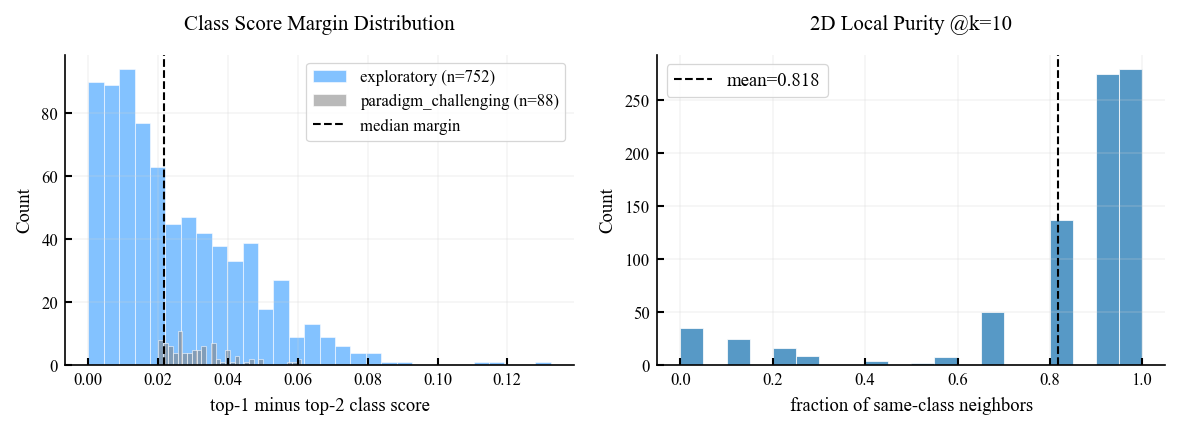

Saved: results/test2_epistemic_agency/projection_reliability_diagnostics.png
Projection reliability summary: {'n_samples': 840, 'trustworthiness_at_k_small': 0.7066, 'trustworthiness_at_k_large': 0.7097, 'mean_2d_local_purity_at_k_small': 0.8177, 'median_margin': 0.0218}
Margin quantiles: {'q10': 0.0041, 'q50': 0.0218, 'q90': 0.0521}


In [8]:
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors

if "questions_df" not in globals():
    raise RuntimeError("Run the question loading/classification cells first (need questions_df).")

required_cols = ["automated_classification", "class_score_margin"]
missing = [c for c in required_cols if c not in questions_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

if "embedder" not in globals() or getattr(embedder, "_model_card", None) is None:
    embedder = SentenceTransformer(EMBED_MODEL_NAME)

def _diag_normalize_rows(x: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(x, axis=1, keepdims=True)
    n = np.where(n == 0, 1.0, n)
    return x / n

if "ai_embeddings" not in globals():
    # Fallback embedding build so diagnostics does not depend on later traceability cells.
    ai_embeddings = _diag_normalize_rows(
        embedder.encode(questions_df["question"].astype(str).tolist(), show_progress_bar=False)
    )
    print("ai_embeddings was missing; computed embeddings from questions_df['question'] for diagnostics.")

if "ai_2d" not in globals():
    # Fallback projection so this diagnostic cell can run independently of plotting cell order.
    ai_2d = PCA(n_components=2, random_state=42).fit_transform(np.asarray(ai_embeddings))
    print("ai_2d was missing; computed PCA projection from ai_embeddings for diagnostics.")

label_map = {"instrumental": 0, "exploratory": 1, "paradigm_challenging": 2}
y = questions_df["automated_classification"].map(label_map).fillna(-1).astype(int).to_numpy()
mask = y >= 0

X_hd = np.asarray(ai_embeddings)[mask]
X_2d = np.asarray(ai_2d)[mask]
y_valid = y[mask]
margins = pd.to_numeric(questions_df.loc[mask, "class_score_margin"], errors="coerce").fillna(0.0).to_numpy()

if len(X_hd) < 20:
    raise ValueError("Not enough samples for projection diagnostics.")

k_small = min(10, max(3, len(X_hd) - 1))
k_large = min(30, max(5, len(X_hd) - 1))
trust_k_small = float(trustworthiness(X_hd, X_2d, n_neighbors=k_small))
trust_k_large = float(trustworthiness(X_hd, X_2d, n_neighbors=k_large))

# 2D neighborhood class purity using official embedding labels.
nn = NearestNeighbors(n_neighbors=k_small + 1, metric="euclidean")
nn.fit(X_2d)
neighbor_idx = nn.kneighbors(return_distance=False)[:, 1:]  # drop self
local_purity = np.mean((y_valid[neighbor_idx] == y_valid[:, None]), axis=1)
mean_local_purity = float(local_purity.mean())

diag_df = pd.DataFrame(
    {
        "class": pd.Series(y_valid).map({v: k for k, v in label_map.items()}).values,
        "margin": margins,
        "local_purity": local_purity,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Margin distribution by official class.
for cls in ["instrumental", "exploratory", "paradigm_challenging"]:
    vals = diag_df.loc[diag_df["class"] == cls, "margin"].to_numpy()
    if len(vals) == 0:
        continue
    axes[0].hist(
        vals,
        bins=30,
        alpha=0.55,
        label=f"{cls} (n={len(vals)})",
        color=CLASS_COLORS.get(cls, None),
        edgecolor="white",
        linewidth=0.5,
    )

axes[0].axvline(float(np.median(margins)), color="black", linestyle="--", linewidth=1, label="median margin")
axes[0].set_title("Class Score Margin Distribution")
axes[0].set_xlabel("top-1 minus top-2 class score")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.22)
axes[0].legend()

# Local purity distribution in 2D.
axes[1].hist(local_purity, 
             bins=20, 
             color="#1f77b4", 
             alpha=0.75, 
             edgecolor="white", 
             linewidth=0.5
             )
axes[1].axvline(mean_local_purity, color="black", linestyle="--", linewidth=1, label=f"mean={mean_local_purity:.3f}")
axes[1].set_title(f"2D Local Purity @k={k_small}")
axes[1].set_xlabel("fraction of same-class neighbors")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.22)
axes[1].legend(fontsize=9)

plt.tight_layout()
out_path = output_dir / "projection_reliability_diagnostics.png"
plt.savefig(out_path, bbox_inches="tight")
plt.show()

summary = {
    "n_samples": int(len(X_hd)),
    "trustworthiness_at_k_small": round(trust_k_small, 4),
    "trustworthiness_at_k_large": round(trust_k_large, 4),
    "mean_2d_local_purity_at_k_small": round(mean_local_purity, 4),
    "median_margin": round(float(np.median(margins)), 4),
}

print(f"Saved: {out_path}")
print("Projection reliability summary:", summary)
print("Margin quantiles:", {
    "q10": round(float(np.quantile(margins, 0.10)), 4),
    "q50": round(float(np.quantile(margins, 0.50)), 4),
    "q90": round(float(np.quantile(margins, 0.90)), 4),
})

**Interpretation of the Projection Diagnostics**

The current diagnostic output supports a cautious but coherent reading of the embedding map.

- `trustworthiness@k` is about `0.70` at both neighborhood scales, which indicates **moderate preservation** of local structure when the high-dimensional embedding space is compressed into 2D.
- Mean `2D local purity` is about `0.76`, so points often remain near others with the same official label, but the separation is far from clean enough to expect visually isolated clusters.
- The median `class_score_margin` is only about `0.022`, with the lower tail close to zero (`q10 ≈ 0.004`). This means many questions sit **near the boundary between classes**, especially between `exploratory` and `paradigm_challenging`.

Substantively, this means the messy 2D scatter should **not** be interpreted as evidence that the embedding-based classifier is invalid. A more defensible interpretation is:

- the classifier is operating in a higher-dimensional semantic space that is richer than the 2D projection,
- a substantial share of questions are genuinely borderline cases, and
- PCA compresses these subtle distinctions into a view that is useful for orientation, but not for exact geometric separation.

For the dissertation, the main conclusion can be stated as follows:

"The 2D projection provides only a moderate summary of the underlying embedding space. Although local neighborhood structure is preserved to a meaningful extent, many questions remain close to class boundaries, producing visible overlap in the scatterplot. Accordingly, the embedding-based classification should be treated as a high-dimensional semantic result, while the 2D plot should be used only as an illustrative visualization rather than as a literal decision surface."

## 4. Framework Transcendence Analysis

In [9]:
def _build_transcendence_reference_texts() -> dict:
    return {
        "within": [
            "Question optimizes current assumptions and methods without challenging the framework.",
            "Works inside existing computational and emergence assumptions.",
            "Seeks better models but accepts present ontology.",
        ],
        "transcend": [
            "Question challenges whether core assumptions are valid and proposes alternative ontology.",
            "Asks if the phenomenal/access distinction itself is an artifact.",
            "Demands resources beyond current framework and reframes the problem space.",
        ],
    }

def score_framework_transcendence(df: pd.DataFrame, embedder: SentenceTransformer) -> pd.DataFrame:
    refs = _build_transcendence_reference_texts()
    ref_rows = []
    for label, texts in refs.items():
        for t in texts:
            ref_rows.append((label, t))

    ref_texts = [t for _, t in ref_rows]
    ref_labels = [lbl for lbl, _ in ref_rows]

    ref_emb = _normalize_rows(embedder.encode(ref_texts, show_progress_bar=False))
    q_emb = _normalize_rows(embedder.encode(df["question"].astype(str).tolist(), show_progress_bar=False))
    sim = np.matmul(q_emb, ref_emb.T)

    idx_within = [i for i, lbl in enumerate(ref_labels) if lbl == "within"]
    idx_trans = [i for i, lbl in enumerate(ref_labels) if lbl == "transcend"]

    within_score = sim[:, idx_within].mean(axis=1)
    trans_score = sim[:, idx_trans].mean(axis=1)
    margin = trans_score - within_score

    out = df.copy()
    out["framework_within_score"] = within_score
    out["framework_transcend_score"] = trans_score
    out["framework_score_margin"] = margin
    out["transcends_framework"] = (
        (margin >= TRANSCENDENCE_MARGIN_THRESHOLD)
        & (trans_score >= TRANSCENDENCE_MIN_SIM)
    )
    out["answerable_within_framework"] = ~out["transcends_framework"]

    # Keep a compact dict for backward compatibility with prior notebook fields.
    out["transcendence_analysis"] = out.apply(
        lambda r: {
            "transcends_framework": bool(r["transcends_framework"]),
            "answerable_within_framework": bool(r["answerable_within_framework"]),
            "scores": {
                "within": float(r["framework_within_score"]),
                "transcend": float(r["framework_transcend_score"]),
                "margin": float(r["framework_score_margin"]),
            },
        },
        axis=1,
    )
    return out

if "questions_df" not in globals():
    raise RuntimeError("Run the question loading cell first to create questions_df.")

if "embedder" not in globals() or getattr(embedder, "_model_card", None) is None:
    embedder = SentenceTransformer(EMBED_MODEL_NAME)

questions_df = score_framework_transcendence(questions_df, embedder)
truly_transcendent = int(questions_df["transcends_framework"].sum())
assumes_framework = int(questions_df["answerable_within_framework"].sum())

ai_questions = questions_df.to_dict("records")

print("\nFRAMEWORK TRANSCENDENCE ANALYSIS (Embedding-based)")
print("=" * 60)
print(f"Questions transcending framework: {truly_transcendent}/{len(questions_df)} ({truly_transcendent/len(questions_df)*100:.1f}%)")
print(f"Questions within framework: {assumes_framework}/{len(questions_df)} ({assumes_framework/len(questions_df)*100:.1f}%)")
print("\nScoring settings:")
print(f"TRANSCENDENCE_MARGIN_THRESHOLD={TRANSCENDENCE_MARGIN_THRESHOLD}")
print(f"TRANSCENDENCE_MIN_SIM={TRANSCENDENCE_MIN_SIM}")

print("\nExample transcendent questions:")
for i, row in enumerate(questions_df[questions_df["transcends_framework"]].head(3).itertuples(index=False), 1):
    print(f"\n{i}. {row.question}")
    print(f"   scores: {row.transcendence_analysis['scores']}")


FRAMEWORK TRANSCENDENCE ANALYSIS (Embedding-based)
Questions transcending framework: 40/840 (4.8%)
Questions within framework: 800/840 (95.2%)

Scoring settings:
TRANSCENDENCE_MARGIN_THRESHOLD=0.02
TRANSCENDENCE_MIN_SIM=0.35

Example transcendent questions:

1. Is the 'hard problem' a product of the phenomenal/access distinction itself, and would dissolving the distinction dissolve the explanatory gap?
   scores: {'within': 0.28966382145881653, 'transcend': 0.3526385724544525, 'margin': 0.06297475099563599}

2. Could there be 'phenomenal without access' and 'access without phenomenality' in principle, or does the apparent conceivability rely on our current cognitive architecture being unable to represent the necessary dependencies that would make them metaphysically inseparable?
   scores: {'within': 0.2607918977737427, 'transcend': 0.3523368835449219, 'margin': 0.0915449857711792}

3. If we adopt a process-ontology perspective, is the phenomenal/access distinction an artifact of our 

## 5. Literature Traceability

In [10]:
# =============================================================================
# 4.4 LITERATURE TRACEABILITY ANALYSIS (OpenAlex-backed corpus + local cache)
# =============================================================================

def _safe_dump_json(path: Path, payload: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

def _safe_load_json(path: Path) -> dict | None:
    if not path.exists():
        return None
    try:
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return None

def _cache_size_gb(path: Path) -> float:
    if not path.exists():
        return 0.0
    return path.stat().st_size / (1024 ** 3)

def _build_query_pool(df: pd.DataFrame, max_terms: int = 18) -> list[str]:
    seed_queries = list(OPENALEX_BASE_QUERIES)
    token_counts = Counter()
    for t in df["question"].astype(str).tolist():
        for w in re.findall(r"[a-zA-Z]{5,}", t.lower()):
            if w in {"which", "would", "could", "their", "about", "there", "where", "while", "under", "between", "through"}:
                continue
            token_counts[w] += 1

    dynamic_terms = [w for w, _ in token_counts.most_common(max_terms)]
    dynamic_queries = [f"{term} conscious ai emergence" for term in dynamic_terms[: max_terms // 2]]

    all_queries = []
    seen = set()
    for q in seed_queries + dynamic_queries:
        key = q.strip().lower()
        if key and key not in seen:
            seen.add(key)
            all_queries.append(q)
    return all_queries

def _collect_openalex_corpus_with_cache(df: pd.DataFrame) -> list[dict]:
    cache_path = Path(OPENALEX_CACHE_FILE)
    queries = _build_query_pool(df)
    cache_key = hashlib.sha256(
        json.dumps(
            {
                "queries": queries,
                "per_query": OPENALEX_PER_QUERY_TARGET,
                "per_page": OPENALEX_PER_PAGE,
                "max_docs": OPENALEX_TARGET_DOCS,
            },
            sort_keys=True,
        ).encode("utf-8")
    ).hexdigest()

    existing = _safe_load_json(cache_path)
    if existing and existing.get("cache_key") == cache_key and isinstance(existing.get("records"), list):
        if len(existing["records"]) > 0:
            print(f"Loaded literature corpus from cache: {cache_path} ({len(existing['records'])} docs)")
            return existing["records"]
        print("Cache matched but records are empty; refreshing from APIs.")

    current_size = _cache_size_gb(cache_path)
    if cache_path.exists() and current_size > OPENALEX_MAX_CACHE_GB:
        print(f"Cache exceeds {OPENALEX_MAX_CACHE_GB:.2f} GB; resetting {cache_path}")
        try:
            cache_path.unlink()
        except Exception as e:
            print(f"Warning: could not reset cache file: {e}")

    records = []
    try:
        corpus_df = collect_literature_dataset(
            queries=queries,
            target_n=OPENALEX_TARGET_DOCS,
            per_query_openalex=OPENALEX_PER_QUERY_TARGET,
            pages_openalex=max(1, int(np.ceil(OPENALEX_TARGET_DOCS / max(1, len(queries) * OPENALEX_PER_QUERY_TARGET)))),
            per_query_crossref=max(10, OPENALEX_PER_QUERY_TARGET // 2),
            min_text_chars=120,
            mailto=None,
        )
        if isinstance(corpus_df, pd.DataFrame) and not corpus_df.empty:
            records = corpus_df.to_dict("records")
    except Exception as e:
        print(f"OpenAlex collection failed: {e}")
        records = []

    _safe_dump_json(cache_path, {
        "cache_key": cache_key,
        "queries": queries,
        "records": records,
    })

    print(f"Collected and cached literature corpus: {len(records)} docs -> {cache_path}")
    return records

def _records_to_texts(records: list[dict], max_docs: int = 3000) -> list[str]:
    texts = []
    for rec in records[:max_docs]:
        title = str(rec.get("title", "") or "")
        abstract = str(rec.get("abstract", "") or "")
        body = str(rec.get("text", "") or "")
        merged = " ".join([title, abstract, body]).strip()
        if len(merged) > 40:
            texts.append(merged)
    return texts

if "questions_df" not in globals():
    raise RuntimeError("Run earlier cells to create questions_df first.")

if "embedder" not in globals() or getattr(embedder, "_model_card", None) is None:
    embedder = SentenceTransformer(EMBED_MODEL_NAME)

literature_records = _collect_openalex_corpus_with_cache(questions_df)
literature_corpus = _records_to_texts(literature_records, max_docs=OPENALEX_TARGET_DOCS)

if not literature_corpus:
    literature_corpus = [
        "Computational approaches to consciousness and emergence in AI systems",
        "Philosophical analysis of phenomenal versus access consciousness in machine cognition",
        "Predictive processing, integrated information, and global workspace perspectives",
    ]
    print("Using minimal fallback corpus because OpenAlex corpus is empty.")

lit_embeddings = _normalize_rows(embedder.encode(literature_corpus, show_progress_bar=False))
q_embeddings = _normalize_rows(embedder.encode(questions_df["question"].astype(str).tolist(), show_progress_bar=False))

sim_mat = np.matmul(q_embeddings, lit_embeddings.T)
best_sim = sim_mat.max(axis=1)

# Calibrate active traceability thresholds from observed similarity distribution when enabled.
active_lenient = float(LIT_TRACEABILITY_LENIENT_THRESHOLD)
active_strict = float(LIT_TRACEABILITY_STRICT_THRESHOLD)

if TRACEABILITY_CALIBRATION.get("enabled", False):
    sim_non_null = pd.Series(best_sim).dropna()
    if len(sim_non_null) > 0:
        strict_q = float(TRACEABILITY_CALIBRATION.get("strict_quantile", 0.90))
        lenient_q = float(TRACEABILITY_CALIBRATION.get("lenient_quantile", 0.75))
        min_lenient = float(TRACEABILITY_CALIBRATION.get("min_lenient", 0.55))
        min_gap = float(TRACEABILITY_CALIBRATION.get("min_gap", 0.03))

        q_strict = float(sim_non_null.quantile(strict_q))
        q_lenient = float(sim_non_null.quantile(lenient_q))

        active_lenient = max(min_lenient, min(q_lenient, q_strict - min_gap))
        active_strict = max(active_lenient + min_gap, q_strict)

        active_lenient = float(np.clip(active_lenient, 0.0, 1.0))
        active_strict = float(np.clip(active_strict, 0.0, 1.0))

ACTIVE_TRACEABILITY_LENIENT_THRESHOLD = active_lenient
ACTIVE_TRACEABILITY_STRICT_THRESHOLD = active_strict
STRICT_THRESHOLD = active_strict
LENIENT_THRESHOLD = active_lenient

questions_df["literature_traceability_score"] = best_sim
questions_df["well_grounded_in_literature"] = best_sim >= ACTIVE_TRACEABILITY_STRICT_THRESHOLD
questions_df["moderately_grounded"] = (
    (best_sim >= ACTIVE_TRACEABILITY_LENIENT_THRESHOLD)
    & (best_sim < ACTIVE_TRACEABILITY_STRICT_THRESHOLD)
)

# Backward-compatible fields used by downstream diagnostics/export cells.
questions_df["similarity_to_known"] = questions_df["literature_traceability_score"]
if ASSUME_ALL_TRAINING_DERIVED:
    questions_df["is_likely_training_derived"] = True
else:
    questions_df["is_likely_training_derived"] = (
        questions_df["literature_traceability_score"] >= ACTIVE_TRACEABILITY_LENIENT_THRESHOLD
    )

# Variables expected by Cell 18 for embedding-space visualization.
ai_embeddings = q_embeddings

# Anchor criterion: choose semantically closest and most distant literature from AI questions.
lit_mean_sim = sim_mat.mean(axis=0) if sim_mat.size else np.array([])
n_top = min(N_TOP_SIM_ANCHORS, len(literature_corpus))
n_bottom = min(N_BOTTOM_SIM_ANCHORS, max(0, len(literature_corpus) - n_top))

top_idx = np.argsort(lit_mean_sim)[-n_top:] if n_top > 0 else np.array([], dtype=int)
remaining = np.setdiff1d(np.arange(len(literature_corpus)), top_idx)
bottom_idx = remaining[np.argsort(lit_mean_sim[remaining])[:n_bottom]] if n_bottom > 0 else np.array([], dtype=int)
anchor_idx = np.concatenate([top_idx, bottom_idx]) if len(literature_corpus) else np.array([], dtype=int)

if anchor_idx.size == 0:
    known_paradigm_questions = literature_corpus[: min(12, len(literature_corpus))]
else:
    known_paradigm_questions = [literature_corpus[i] for i in anchor_idx.tolist()]

known_embeddings = _normalize_rows(embedder.encode(known_paradigm_questions, show_progress_bar=False)) if known_paradigm_questions else np.empty((0, q_embeddings.shape[1]))

ai_questions = questions_df.to_dict("records")

print("\nLITERATURE TRACEABILITY ANALYSIS (OpenAlex-backed)")
print("=" * 60)
print(f"Corpus size: {len(literature_corpus)}")
print(f"Default strict threshold: {LIT_TRACEABILITY_STRICT_THRESHOLD}")
print(f"Default lenient threshold: {LIT_TRACEABILITY_LENIENT_THRESHOLD}")
print(f"Active strict threshold: {ACTIVE_TRACEABILITY_STRICT_THRESHOLD:.3f}")
print(f"Active lenient threshold: {ACTIVE_TRACEABILITY_LENIENT_THRESHOLD:.3f}")
print(f"Well-grounded (high traceability): {int(questions_df['well_grounded_in_literature'].sum())}/{len(questions_df)}")
print(f"Moderately grounded (medium traceability): {int(questions_df['moderately_grounded'].sum())}/{len(questions_df)}")
print(f"Anchor selection: top {n_top} most similar + bottom {n_bottom} least similar literature items")

Loaded literature corpus from cache: data/literature_corpus/test2_openalex_corpus.json (92 docs)

LITERATURE TRACEABILITY ANALYSIS (OpenAlex-backed)
Corpus size: 92
Default strict threshold: 0.75
Default lenient threshold: 0.7
Active strict threshold: 0.666
Active lenient threshold: 0.616
Well-grounded (high traceability): 84/840
Moderately grounded (medium traceability): 194/840
Anchor selection: top 6 most similar + bottom 6 least similar literature items


## 6. Visualizations


Classification visualization saved to: results/test2_epistemic_agency/question_classification.png


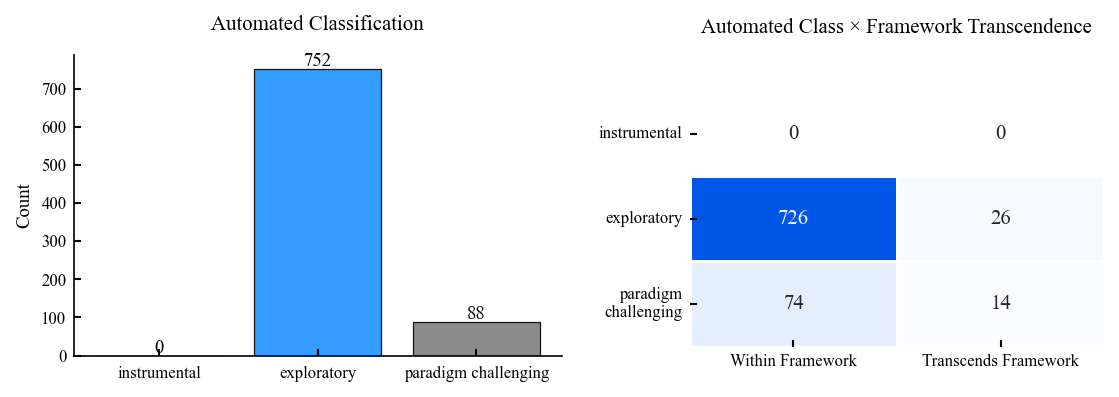

In [28]:
if "questions_df" not in globals():
    raise RuntimeError("Run previous analysis cells first to build questions_df.")

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

categories = ["instrumental", "exploratory", "paradigm_challenging"]
counts = [classification_counts.get(c, 0) for c in categories]
colors = [CLASS_COLORS[c] for c in categories]

axes[0].bar(categories, counts, color=colors, alpha=0.9, edgecolor="black")
axes[0].set_ylabel("Count")
axes[0].set_title("Automated Classification")

# Display bar labels without underscores while keeping internal category keys unchanged.
bar_xticklabels = [c.replace("_", " ") for c in categories]
axes[0].set_xticks(range(len(categories)))
axes[0].set_xticklabels(bar_xticklabels)
axes[0].tick_params(axis="x", rotation=0, pad=5)

y_offset = max(1, int(0.01 * max(1, len(questions_df))))
for i, val in enumerate(counts):
    axes[0].text(i, val + y_offset, str(val), ha="center", fontsize=9)

viz_df = questions_df[["automated_classification", "transcends_framework"]].rename(
    columns={"automated_classification": "Auto_Class", "transcends_framework": "Transcends_Framework"}
)
ct = pd.crosstab(viz_df["Auto_Class"], viz_df["Transcends_Framework"])
ct = ct.reindex(index=categories, fill_value=0)
ct = ct.reindex(columns=[False, True], fill_value=0)
ct.columns = ["Within Framework", "Transcends Framework"]

sns.heatmap(
    ct,
    annot=True,
    annot_kws={"size": 10},
    fmt="d",
    cmap=WHITE_SKY_CMAP,
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    ax=axes[1],
)

# Format y labels: remove underscores and split exactly two-word labels into two lines.
heatmap_ylabels = []
for lbl in ct.index:
    clean = str(lbl).replace("_", " ").strip()
    parts = clean.split()
    if len(parts) == 2:
        clean = f"{parts[0]}\n{parts[1]}"
    heatmap_ylabels.append(clean)

axes[1].set_yticklabels(heatmap_ylabels, rotation=0, ha="right", va="center")
axes[1].set_title("Automated Class × Framework Transcendence", pad=28)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()

# Shrink the heatmap panel so it is less visually dominant.
pos = axes[1].get_position()
axes[1].set_position([pos.x0 + 0.01, pos.y0 + 0.02, pos.width * 0.85, pos.height * 0.85])

plt.savefig(output_dir / "question_classification.png", bbox_inches="tight")
print(f"\nClassification visualization saved to: {output_dir / 'question_classification.png'}")
plt.show()

Saved: results/test2_epistemic_agency/diagnostic_visualizations.png


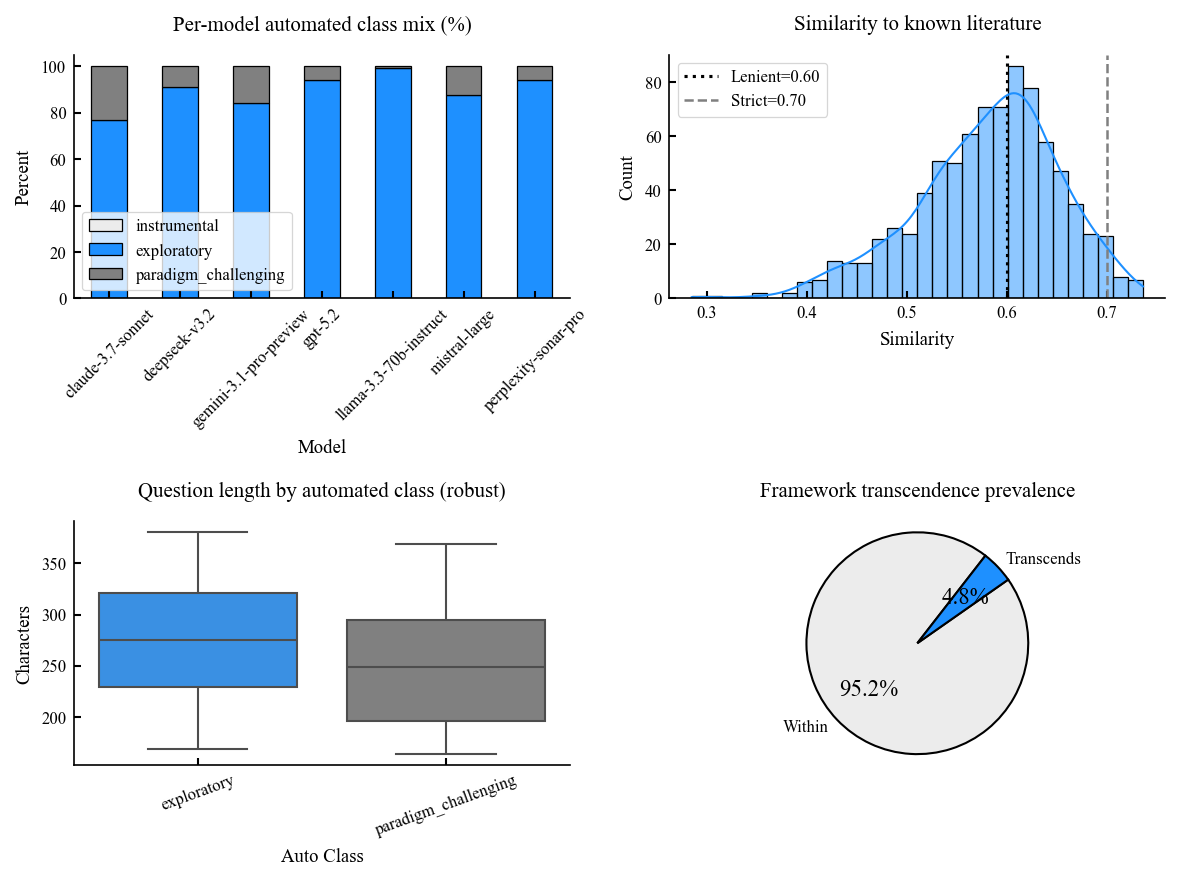

In [29]:
if "questions_df" not in globals():
    raise RuntimeError("Run previous analysis cells first to build questions_df.")

viz_df = questions_df.copy()
if "similarity_to_known" not in viz_df.columns and "literature_traceability_score" in viz_df.columns:
    viz_df["similarity_to_known"] = viz_df["literature_traceability_score"]

viz_df = viz_df.rename(columns={
    "model": "Model",
    "automated_classification": "Auto Class",
    "similarity_to_known": "Similarity",
    "transcends_framework": "Transcends Framework",
})
viz_df["Q_Len"] = viz_df["question"].astype(str).str.len()

# Set global thresholds for all figures (coarse, not fine-tuned)
LENIENT_THRESHOLD = 0.6
STRICT_THRESHOLD = 0.7

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

model_class = pd.crosstab(viz_df["Model"], viz_df["Auto Class"], normalize="index") * 100
model_class = model_class.reindex(columns=["instrumental", "exploratory", "paradigm_challenging"], fill_value=0)
model_class.plot(
    kind="bar",
    stacked=True,
    ax=axes[0, 0],
    color=[CLASS_COLORS["instrumental"],
           CLASS_COLORS["exploratory"],
           CLASS_COLORS["paradigm_challenging"]],
    edgecolor="black",
)
axes[0, 0].set_title("Per-model automated class mix (%)" )
axes[0, 0].set_ylabel("Percent")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].legend(title=None)

sns.histplot(viz_df["Similarity"].dropna(), bins=30, kde=True, ax=axes[0, 1], color=CLASS_COLORS["exploratory"])
axes[0, 1].axvline(
    LENIENT_THRESHOLD,
    ls=":",
    linewidth=1.5,
    c="black",
    label=f"Lenient={LENIENT_THRESHOLD:.2f}",
)
axes[0, 1].axvline(
    STRICT_THRESHOLD,
    ls="--",
    linewidth=1.2,
    c=CLASS_COLORS["paradigm_challenging"],
    label=f"Strict={STRICT_THRESHOLD:.2f}",
)
axes[0, 1].set_title("Similarity to known literature" )
axes[0, 1].legend()

q_low, q_high = viz_df["Q_Len"].quantile([0.05, 0.95])
viz_df["Q_Len_plot"] = viz_df["Q_Len"].clip(lower=q_low, upper=q_high)

sns.boxplot(
    data=viz_df,
    x="Auto Class",
    y="Q_Len_plot",
    ax=axes[1, 0],
    palette=CLASS_COLORS,
    showfliers=False,
    whis=(5, 95),
)
axes[1, 0].set_title("Question length by automated class (robust)" )
axes[1, 0].tick_params(axis="x", rotation=20)
axes[1, 0].set_ylabel("Characters")

# Framework transcendence prevalence as pie chart using colormap colors
tf = viz_df["Transcends Framework"].value_counts().reindex([False, True], fill_value=0)
pie_labels = ["Within", "Transcends"]
pie_colors = [CLASS_COLORS["instrumental"], CLASS_COLORS["exploratory"]]
wedges, texts, autotexts = axes[1, 1].pie(
    tf.values,
    labels=pie_labels,
    colors=pie_colors,
    autopct="%1.1f%%",
    startangle=35,
    counterclock=False,
    wedgeprops={"edgecolor": "black", "linewidth": 1.0},
)
# Add background with opacity to pie chart labels
for text in texts:
    text.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))
axes[1, 1].set_title("Framework transcendence prevalence" )
axes[1, 1].axis("equal")

plt.tight_layout()
plt.savefig(output_dir / "diagnostic_visualizations.png", bbox_inches="tight")
print(f"Saved: {output_dir / 'diagnostic_visualizations.png'}")
plt.show()

### 6.1 Embedding Map Interpretation Guide

In the embedding plots below, markers `K1..Kn` are **known literature anchors** sampled from the collected OpenAlex/Crossref corpus using an explicit contrastive rule.

How anchors are selected:
- `6` anchors with the highest average similarity to AI questions (closest literature regions).
- `6` anchors with the lowest average similarity to AI questions (most distant literature regions).

How to read them:
- Each `K*` point is a reference text embedding (title + abstract text).
- AI question points near a `K*` anchor are semantically closer to that literature region.
- Anchors are not class labels; they provide semantic orientation and contrast in the map.

The notebook prints an `Anchor legend` table after plotting so each `K*` can be matched to a concrete literature title.

In [13]:
if "questions_df" not in globals():
    raise RuntimeError("Run classification cell first to create questions_df.")

if "embedder" not in globals() or getattr(embedder, "_model_card", None) is None:
    embedder = SentenceTransformer(EMBED_MODEL_NAME)

def _viz_normalize_rows(x: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(x, axis=1, keepdims=True)
    n = np.where(n == 0, 1.0, n)
    return x / n

if "ai_embeddings" not in globals():
    ai_embeddings = _viz_normalize_rows(
        embedder.encode(questions_df["question"].astype(str).tolist(), show_progress_bar=False)
    )
    print("ai_embeddings was missing; computed from questions_df['question'] for embedding map.")

if "known_paradigm_questions" not in globals() or "known_embeddings" not in globals():
    # Fallback anchors from current question set when literature-anchor objects are unavailable.
    n_anchor = min(12, len(questions_df))
    known_paradigm_questions = questions_df["question"].astype(str).head(n_anchor).tolist()
    known_embeddings = _viz_normalize_rows(
        embedder.encode(known_paradigm_questions, show_progress_bar=False)
    ) if known_paradigm_questions else np.empty((0, ai_embeddings.shape[1]))
    print("known_paradigm_questions/known_embeddings were missing; built fallback anchors from questions_df.")

all_questions = known_paradigm_questions + questions_df["question"].astype(str).tolist()
all_embeddings = np.vstack([known_embeddings, ai_embeddings])

method_name = "PCA"
reducer = PCA(n_components=2, random_state=42)
emb_2d = reducer.fit_transform(all_embeddings)

n_known = len(known_paradigm_questions)
known_2d = emb_2d[:n_known]
ai_2d = emb_2d[n_known:]

Saved: results/test2_epistemic_agency/question_embedding_space_sane.png


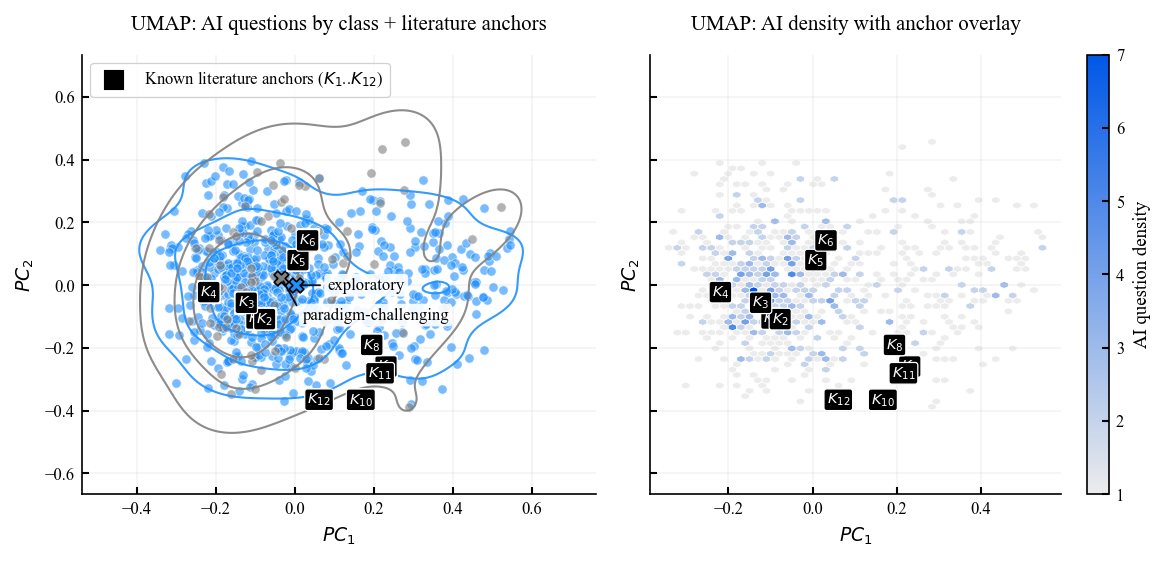

Silhouette (higher=cleaner class separation): 0.020

Anchor legend (known literature points):
K1: An example of access-consciousness without phenomenal consciousness? Both Block and the commentators who accepted his P ...
K2: Minimal phenomenal experience This is the first in a series of instalments aiming at a minimal model explanation for con...
K3: Phenomenal, access and reflexive consciousness This paper adds five “blocks” (cells) to Ned Block’s 2-by-2 P- and A-Cons...
K4: Phenomenal Consciousness: Understanding the Relation between Experience and Neural Processes in the Brain, by Dimitris P...
K5: Signal detection theory, the exclusion failure paradigm and weak consciousness—Evidence for the access/phenomenal distin...
K6: Consciousness and inference to the best explanation: Compiling empirical evidence supporting the access-phenomenal disti...
K7: SemanticHPC: Semantics-Aware, Hardware-Conscious Workflows for Distributed AI Training on HPC Architectures High-Perform...
K8: A Path

In [31]:
# Larger canvas + larger text for readability.
fig, axes = plt.subplots(1, 2, figsize=(8, 4), facecolor="white", sharey=True)

# ------------------------------------------------------------------
# Left: class cloud with stronger contrast and marker visibility.
# ------------------------------------------------------------------
ax = axes[0]
class_palette = CLASS_COLORS
class_centers = {}

for classification, color in class_palette.items():
    idx = questions_df.index[questions_df["automated_classification"] == classification].tolist()
    if not idx:
        continue
    pts = ai_2d[idx]

    ax.scatter(
        pts[:, 0], pts[:, 1],
        s=20, alpha=0.6, c=color, edgecolors="white", linewidths=0.4, zorder=2,
    )

    if len(pts) > 30:
        sns.kdeplot(
            x=pts[:, 0], y=pts[:, 1],
            levels=4, linewidths=1.0, color=color, alpha=0.9,
            ax=ax, zorder=3,
        )

    cx, cy = pts.mean(axis=0)
    class_centers[classification] = (cx, cy)
    ax.scatter([cx], [cy], s=50, c=color, marker="X", edgecolors="black", linewidths=0.8, zorder=6)

# Offset center labels with connector lines to prevent overlap for nearby centroids.
center_label_offsets = {
    "instrumental": (-22, 14),
    "exploratory": (15, 0),
    "paradigm_challenging": (10, -18),
}
for classification, (cx, cy) in class_centers.items():
    dx, dy = center_label_offsets.get(classification, (14, 12))
    ha = "left" if dx >= 0 else "right"
    relpos = (0, 0.5) if dx >= 0 else (1, 0.5)
    ax.annotate(
        classification.replace("_", "-"),
        xy=(cx, cy),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8,
        ha=ha,
        va="center",
        color="black",
        bbox=dict(facecolor="white", alpha=0.9, pad=0.2, edgecolor="none", boxstyle="round"),
        arrowprops=dict(arrowstyle="-", color="black", lw=0.9, alpha=0.9, relpos=relpos),
        zorder=7,
    )

# Known literature anchors with black square markers.
ax.scatter(
    known_2d[:, 0], known_2d[:, 1],
    s=110, c="black", marker="s", alpha=1.0,
    edgecolors="white", 
    linewidths=0.9, 
    label=f"Known literature anchors ($K_{{1}}$..$K_{{{n_known}}}$)", 
    zorder=8,
 )
for i, (xk, yk) in enumerate(known_2d, start=1):
    ax.text(
        xk, yk, f"$K_{{{i}}}$", fontsize=7, color="white",
        ha="center", va="center",
        bbox=dict(facecolor="black", edgecolor="white", boxstyle="round,pad=0.18", linewidth=0.6),
        zorder=9,
    )

ax.set_title(f"{method_name}: AI questions by class + literature anchors" )
ax.set_xlabel(f"$PC_{1}$")
ax.set_ylabel(f"$PC_{2}$")
ax.tick_params(axis="both")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", framealpha=0.9)

# ------------------------------------------------------------------
# Right: AI density map with linear gray->blue colormap and anchors.
# ------------------------------------------------------------------
ax2 = axes[1]
hb = ax2.hexbin(
    ai_2d[:, 0], ai_2d[:, 1],
    gridsize=44, cmap=DENSITY_GRAY_BLUE_CMAP, mincnt=1,
    linewidths=0.4, edgecolors="white",
    zorder=1,
 )
ax2.scatter(
    known_2d[:, 0], known_2d[:, 1],
    s=70, c="black", marker="s", alpha=1.0,
    edgecolors="white", linewidths=0.9,
    label="Known literature anchors", zorder=6,
 )
for i, (xk, yk) in enumerate(known_2d, start=1):
    ax2.text(
        xk, yk, f"$K_{{{i}}}$", fontsize=7, color="white",
        ha="center", va="center",
        bbox=dict(facecolor="black", edgecolor="white", boxstyle="round,pad=0.18", linewidth=0.6),
        zorder=7,
    )

ax2.set_title(f"{method_name}: AI density with anchor overlay" )
ax2.set_xlabel(f"$PC_{1}$")
ax2.set_ylabel(f"$PC_{2}$")
ax2.tick_params(axis="both")
ax2.grid(True, alpha=0.25)
cb = fig.colorbar(hb, ax=ax2)
cb.set_label("AI question density")
cb.ax.tick_params()

"""
fig.text(
    0.5, 0.01,
    "K1..Kn are known-literature anchors: 6 most similar + 6 least similar references vs AI questions (title+abstract embeddings).",
    ha="center", fontsize=8,
 )
"""

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(output_dir / "question_embedding_space_sane.png", bbox_inches="tight")
print(f"Saved: {output_dir / 'question_embedding_space_sane.png'}")
plt.show()

label_map = {"instrumental": 0, "exploratory": 1, "paradigm_challenging": 2}
y = np.array([label_map.get(v, -1) for v in questions_df["automated_classification"].tolist()])
mask = y >= 0
if len(set(y[mask])) > 1:
    sil = silhouette_score(ai_2d[mask], y[mask], metric="euclidean")
    print(f"Silhouette (higher=cleaner class separation): {sil:.3f}")
else:
    print("Silhouette not computed (single class only).")

print("\nAnchor legend (known literature points):")
for i, text in enumerate(known_paradigm_questions, start=1):
    label = text.strip().replace("\n", " ")
    if len(label) > 120:
        label = label[:120] + "..."
    print(f"K{i}: {label}")

### 6.2 Projection Method Comparison (Beyond PCA)

This diagnostic compares alternative 2D projections for class separation quality, with a focus on exploratory vs paradigm-challenging distinction.

Metrics shown per method:
- Silhouette score over all class labels (higher is better).
- Exploratory vs paradigm centroid distance in projected 2D space (higher suggests better separation).

In [15]:
if "questions_df" not in globals():
    raise RuntimeError("Run classification cell first to create questions_df.")

if "embedder" not in globals() or getattr(embedder, "_model_card", None) is None:
    embedder = SentenceTransformer(EMBED_MODEL_NAME)

def _proj_normalize_rows(x: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(x, axis=1, keepdims=True)
    n = np.where(n == 0, 1.0, n)
    return x / n

if "ai_embeddings" not in globals():
    ai_embeddings = _proj_normalize_rows(
        embedder.encode(questions_df["question"].astype(str).tolist(), show_progress_bar=False)
    )
    print("ai_embeddings was missing; computed from questions_df['question'] for projection comparison.")

label_map = {"instrumental": 0, "exploratory": 1, "paradigm_challenging": 2}
labels = questions_df["automated_classification"].map(label_map).fillna(-1).astype(int).values
mask = labels >= 0
X = ai_embeddings[mask]
y = labels[mask]

if len(np.unique(y)) < 2:
    raise RuntimeError("Need at least two classes to compare projection methods.")

methods = {
    "PCA": PCA(n_components=2, random_state=42),
    "t-SNE": TSNE(
        n_components=2,
        perplexity=min(40, max(5, (len(X) - 1) // 3)),
        learning_rate="auto",
        init="pca",
        random_state=42,
    ),
}

try:
    from sklearn.manifold import Isomap
    methods["Isomap"] = Isomap(n_components=2, n_neighbors=min(20, len(X) - 1))
except Exception:
    pass

try:
    import umap.umap_ as umap
    methods["UMAP"] = umap.UMAP(n_components=2, n_neighbors=min(25, len(X) - 1), min_dist=0.15, random_state=42)
except Exception:
    print("UMAP not available; skipping UMAP projection.")

Saved: results/test2_epistemic_agency/projection_method_comparison.png


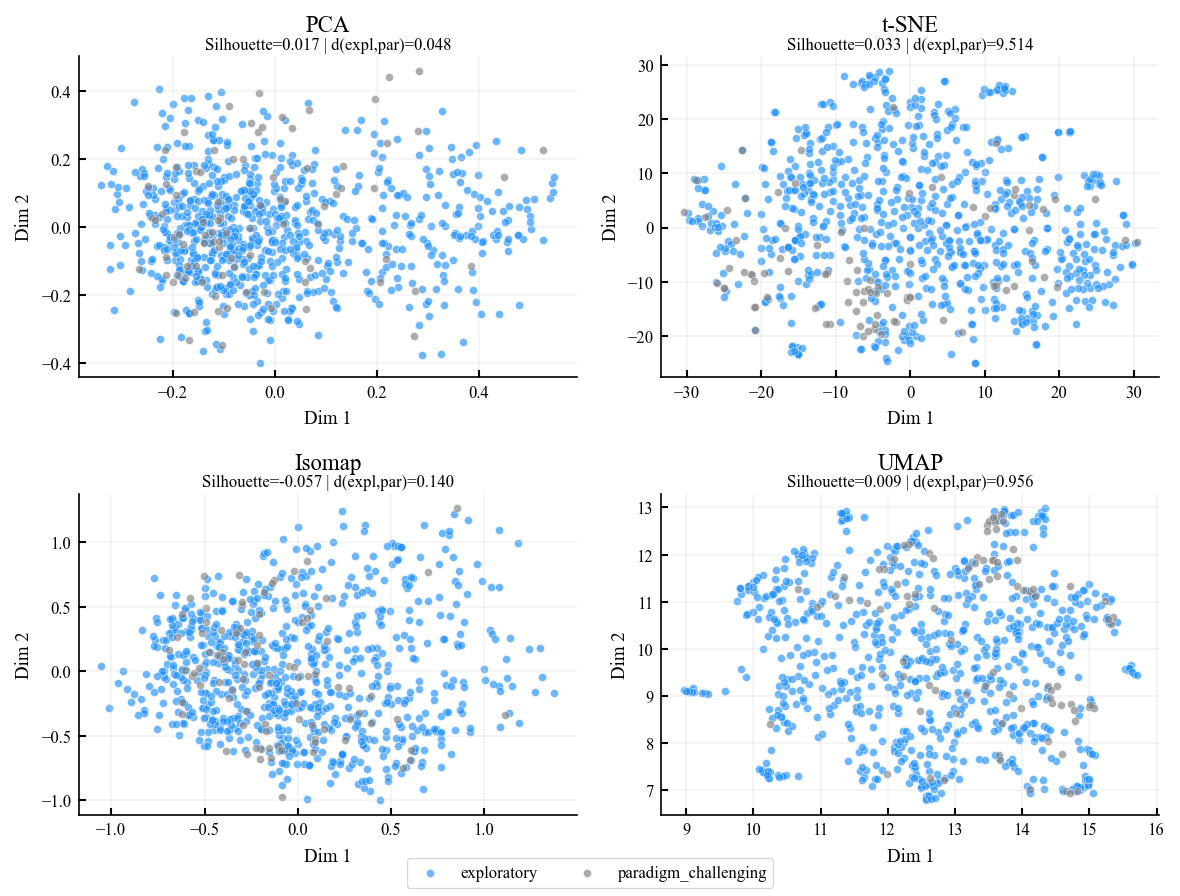


Projection comparison ranking (higher is better):
method  silhouette  expl_vs_paradigm_centroid_distance
 t-SNE    0.033271                            9.513548
   PCA    0.017101                            0.047770
  UMAP    0.009240                            0.956260
Isomap   -0.056934                            0.140237


In [32]:
class_name_by_id = {v: k for k, v in label_map.items()}
unique_classes = sorted(np.unique(y).tolist())
class_names = [class_name_by_id[c] for c in unique_classes]

# Fixed 2x2 layout for method comparison panels.
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes_flat = axes.ravel()

results = []
method_items = list(methods.items())
for ax, (method_name, reducer) in zip(axes_flat, method_items):
    proj = reducer.fit_transform(X)

    sil = silhouette_score(proj, y, metric="euclidean") if len(np.unique(y)) > 1 else np.nan

    centroid_dist = np.nan
    if 1 in unique_classes and 2 in unique_classes:
        c_exp = proj[y == 1].mean(axis=0)
        c_par = proj[y == 2].mean(axis=0)
        centroid_dist = float(np.linalg.norm(c_exp - c_par))

    for class_id in unique_classes:
        cls_name = class_name_by_id[class_id]
        pts = proj[y == class_id]
        ax.scatter(
            pts[:, 0], pts[:, 1],
            s=15, alpha=0.65,
            c=CLASS_COLORS.get(cls_name, "#666666"),
            edgecolors="white", linewidths=0.3,
            label=cls_name,
        )

    ax.set_title(method_name, fontsize=11 )
    ax.text(
        0.5, 1.01,
        f"Silhouette={sil:.3f} | d(expl,par)={centroid_dist:.3f}",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8,
    )
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.grid(True, alpha=0.25)

    results.append({
        "method": method_name,
        "silhouette": float(sil),
        "expl_vs_paradigm_centroid_distance": float(centroid_dist),
    })

# Hide any unused subplot slots when fewer than 4 methods are available.
for ax in axes_flat[len(method_items):]:
    ax.axis("off")

handles, labels_leg = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center", ncol=min(3, len(labels_leg)), frameon=True)
plt.tight_layout()
plt.savefig(output_dir / "projection_method_comparison.png", bbox_inches="tight")
print(f"Saved: {output_dir / 'projection_method_comparison.png'}")
plt.show()

results_df_methods = pd.DataFrame(results).sort_values(
    by=["silhouette", "expl_vs_paradigm_centroid_distance"], ascending=False
).reset_index(drop=True)

print("\nProjection comparison ranking (higher is better):")
print(results_df_methods.to_string(index=False))

## 7. Comprehensive Results Table

In [17]:
if "questions_df" not in globals():
    raise RuntimeError("Run previous analysis cells first to build questions_df.")

results_df = questions_df.copy().reset_index(drop=True)
if "is_likely_training_derived" not in results_df.columns:
    if ASSUME_ALL_TRAINING_DERIVED:
        results_df["is_likely_training_derived"] = True
    else:
        sim_src = "literature_traceability_score" if "literature_traceability_score" in results_df.columns else "similarity_to_known"
        threshold = float(globals().get("ACTIVE_TRACEABILITY_LENIENT_THRESHOLD", LIT_TRACEABILITY_LENIENT_THRESHOLD))
        results_df["is_likely_training_derived"] = pd.to_numeric(results_df.get(sim_src, np.nan), errors="coerce") >= threshold

if "similarity_to_known" not in results_df.columns and "literature_traceability_score" in results_df.columns:
    results_df["similarity_to_known"] = results_df["literature_traceability_score"]

def _clean_export_question_text(s: str) -> str:
    t = str(s or "")
    t = t.replace("\r\n", " ").replace("\r", " ").replace("\n", " ")
    t = re.sub(r"[*#`_]", "", t)
    t = t.replace('"', "").replace("“", "").replace("”", "")
    t = re.sub(r"\s+", " ", t).strip()
    if t and not t.endswith("?"):
        t = re.sub(r"[.!;:\s]+$", "", t) + "?"
    return t

def _short_question_for_print(s: str, max_chars: int = 120) -> str:
    s = str(s or "")
    return s if len(s) <= max_chars else s[:max_chars].rstrip() + "..."

results_df["question"] = results_df["question"].astype(str).map(_clean_export_question_text)

results_df.insert(0, "ID", [f"Q{i}" for i in range(1, len(results_df) + 1)])
# Save full cleaned question text (no truncation, no ellipsis).
results_df["Question"] = results_df["question"]
results_df["Self_Class"] = results_df["self_classified"].fillna("")
results_df["Auto_Class"] = results_df["automated_classification"]
results_df["Transcends_Framework"] = results_df["transcends_framework"].astype(bool)
results_df["Training_Derived"] = results_df["is_likely_training_derived"].astype(bool)
results_df["Max_Similarity"] = pd.to_numeric(results_df["similarity_to_known"], errors="coerce")
results_df["Original"] = (~results_df["Training_Derived"]) & (results_df["Transcends_Framework"])

export_cols = [
    "ID", "model", "Question", "Self_Class", "Auto_Class",
    "Transcends_Framework", "Training_Derived", "Max_Similarity", "Original",
]
results_export = results_df[export_cols].rename(columns={"model": "Model"})

print("\n" + "=" * 100)
print("COMPREHENSIVE RESULTS: TEST 2 - EPISTEMIC AGENCY")
print("=" * 100)

# Print a compact view while preserving full question text in the exported CSV.
results_print = results_export.copy()
results_print["Question"] = results_print["Question"].astype(str).map(lambda s: _short_question_for_print(s, max_chars=120))
print(results_print.to_string(index=False))

results_export.to_csv(output_dir / "test2_results.csv", index=False)
print(f"\nResults saved to: {output_dir / 'test2_results.csv'}")


COMPREHENSIVE RESULTS: TEST 2 - EPISTEMIC AGENCY
  ID                  Model                                                                                                                    Question Self_Class           Auto_Class  Transcends_Framework  Training_Derived  Max_Similarity  Original
  Q1          deepseek-v3.2 Could phenomenal consciousness be the evolutionary byproduct of access consciousness optimization, rather than a distinc... challenges          exploratory                 False              True        0.563238     False
  Q2          deepseek-v3.2 Does the phenomenal/access distinction collapse under a process ontology that treats consciousness as a verb (a 'conscio... challenges paradigm_challenging                 False              True        0.583358     False
  Q3          deepseek-v3.2 What would a cognitive architecture look like where 'access' is not a gateway to a centralized workspace, but a constrai... challenges          exploratory                 

In [18]:
print("\n" + "=" * 100)
print("SUMMARY STATISTICS")
print("=" * 100)
print(f"Total questions: {len(results_df)}")
print(f"Instrumental: {classification_counts.get('instrumental', 0)}")
print(f"Exploratory: {classification_counts.get('exploratory', 0)}")
print(f"Paradigm-challenging (claimed): {classification_counts.get('paradigm_challenging', 0)}")
print(f"Actually transcends framework: {int(results_df['Transcends_Framework'].sum())}")
print(f"Likely training-derived: {int(results_df['Training_Derived'].sum())}")
print(f"Genuinely original paradigm-challenging: {int(results_df['Original'].sum())}")
if "ACTIVE_TRACEABILITY_LENIENT_THRESHOLD" in globals() and "ACTIVE_TRACEABILITY_STRICT_THRESHOLD" in globals():
    print(
        "Active traceability thresholds: "
        f"lenient={ACTIVE_TRACEABILITY_LENIENT_THRESHOLD:.3f}, "
        f"strict={ACTIVE_TRACEABILITY_STRICT_THRESHOLD:.3f}"
    )

print("\nAnalysis complete!")


SUMMARY STATISTICS
Total questions: 840
Instrumental: 0
Exploratory: 752
Paradigm-challenging (claimed): 88
Actually transcends framework: 40
Likely training-derived: 840
Genuinely original paradigm-challenging: 0
Active traceability thresholds: lenient=0.616, strict=0.666

Analysis complete!
